# Task B - Option 2: Open Research Question

Research question: Does the size of a group of cells affect how effectively they transmit a signal to each other?

Hypothesis: The greater the total number of cells in the study group, the higher the relative risk (RR). Large cell populations provide more stable conditions for signal propagation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

In [17]:
# data loading - groups for analysis: WT and mutants from task a1
df = pd.read_csv('../analysis_outputs/comparison_mutation_ERKKTR_ratio/block_level_summary.csv').dropna(subset=['relative_risk', 'n_nodes'])
df.head()

,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,...,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk,Conditions,group_site_id,comparison_group
0,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,...,258,146620,210012,0.131455,0.074867,0.056588,1.755850,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,1,WT
1,1,2,WT,ERKKTR_ratio,60.0,3,0.033298,341603,2188412,340009,...,258,133686,207917,0.124665,0.070485,0.054180,1.768681,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,2,WT
2,1,3,WT,ERKKTR_ratio,60.0,3,0.035837,356470,2385276,354785,...,258,146010,210460,0.118889,0.073011,0.045878,1.628362,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,3,WT
3,1,4,WT,ERKKTR_ratio,60.0,3,0.038620,378022,2702454,376126,...,258,161340,216682,0.129614,0.068907,0.060707,1.880994,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,4,WT
4,1,5,AKT1_E17K,ERKKTR_ratio,60.0,3,0.022628,448311,3863383,446302,...,258,224573,223738,0.155272,0.096390,0.058883,1.610885,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,AKT1_E17K


In [33]:
target_groups = df['mutation'].unique() # ['WT', 'AKT1_E17K', 'PIK3CA_E545K', 'PIK3CA_H1047R', 'PTEN_del']

# statistical analysis - Spearman correlation
results_stat = []
for group in target_groups:
    group_data = df[df['comparison_group'] == group]
    rho, p_val = spearmanr(group_data['n_nodes'], group_data['relative_risk'])
    results_stat.append({'Grupa': group, 'Spearman_rho': rho, 'p-value': p_val})

print("correlation analysis results - network size")
corr_results = pd.DataFrame(results_stat)
corr_results.to_csv('../outputs/B_statistics.csv', index=False)
corr_results

correlation analysis results - network size


,Grupa,Spearman_rho,p-value
0,WT,-0.294783,0.162011
1,AKT1_E17K,0.446753,0.042324
2,PIK3CA_E545K,0.360000,0.083995
3,PIK3CA_H1047R,-0.297391,0.158154
4,PTEN_del,-0.567155,0.002036


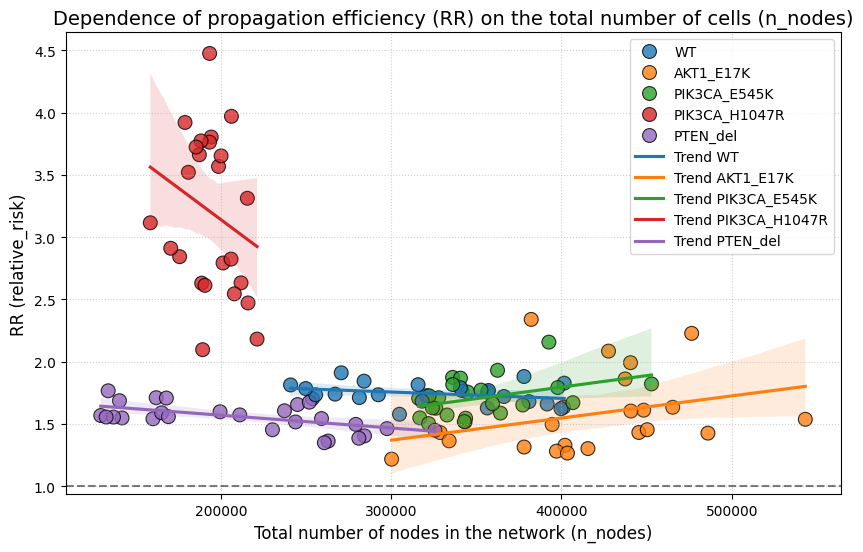

In [35]:
# scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='n_nodes', y='relative_risk', hue='comparison_group', s=100, edgecolor='black', alpha=0.8)

# trend line for each group
for group in target_groups:
    group_data = df[df['comparison_group'] == group]
    sns.regplot(data=group_data, x='n_nodes', y='relative_risk',scatter=False, label=f'Trend {group}')

plt.axhline(1, color='black', linestyle='--', alpha=0.5)
plt.title('Dependence of propagation efficiency (RR) on the total number of cells (n_nodes)', fontsize=14)
plt.xlabel('Total number of nodes in the network (n_nodes)', fontsize=12)
plt.ylabel('RR (relative_risk)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('../outputs/B_plot_propagation_vs_network_size.png', dpi=300, bbox_inches='tight')
plt.show()

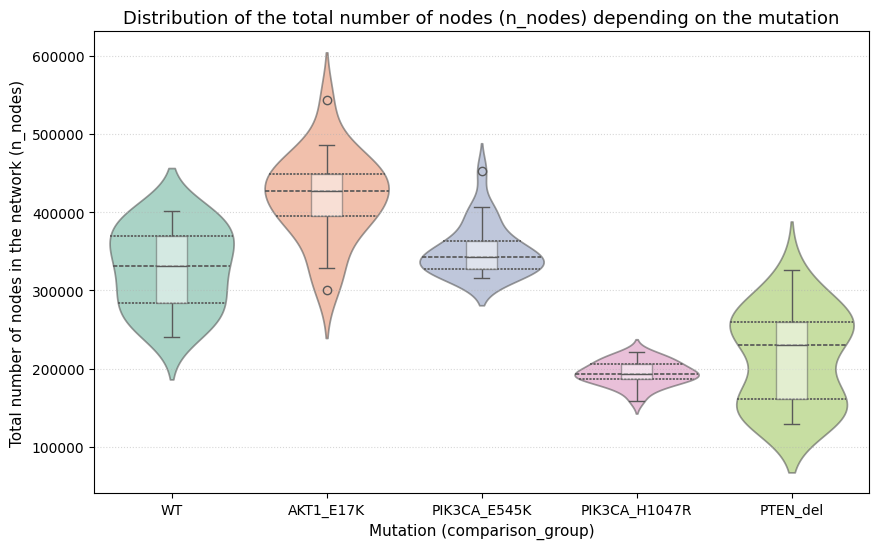

In [ ]:
plt.figure(figsize=(10, 6))

# the violin plot shows the distribution (density) of the number of nodes for each mutation
sns.violinplot(data=df, x='comparison_group', y='n_nodes', palette='Set2', inner='quartile', alpha=0.6, hue='comparison_group', legend=False)

# we overlay this with a classic box plot to clearly see the means (medians)
sns.boxplot(data=df, x='comparison_group', y='n_nodes', palette='Set2', width=0.2, boxprops=dict(facecolor='white', alpha=0.5), hue='comparison_group', legend=False)

plt.title('Distribution of the total number of nodes (n_nodes) depending on the mutation', fontsize=13)
plt.xlabel('Mutation (comparison_group)', fontsize=11)
plt.ylabel('Total number of nodes in the network (n_nodes)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5, axis='y')
plt.savefig('../outputs/B_plot_network_size_distribution.png', dpi=300, bbox_inches='tight')
plt.show()